# 🏥 Clinical Named Entity Recognition (NER)
## Extracting Diseases, Drugs & Dosages from Patient Notes

**Course:** Natural Language Processing  
**Domain:** Clinical / Biomedical NLP  
**Model:** Bidirectional LSTM with CRF (BiLSTM-CRF)

---

## 📌 Project Overview

Electronic Health Records (EHRs) contain a vast amount of unstructured clinical text — doctor's notes, discharge summaries, radiology reports — where critical medical information is buried in free-form language. **Clinical NER** is the task of automatically identifying and categorizing medical entities from this text.

This project builds a complete NLP pipeline to extract three entity types:

| Entity | Tag | Example |
|---|---|---|
| **Disease / Condition** | `DISEASE` | *type 2 diabetes*, *hypertension*, *pneumonia* |
| **Drug / Medication** | `DRUG` | *metformin*, *lisinopril*, *amoxicillin* |
| **Dosage / Strength** | `DOSAGE` | *500mg*, *10mg twice daily*, *2 tablets* |

### Why This Matters
- Hospitals use Clinical NER to auto-populate structured EHR fields
- Pharma companies use it to mine adverse drug reactions from clinical notes
- Insurers use it for automated claims processing and ICD-10 coding
- Researchers use it to power clinical trial cohort identification

---

## ⚙️ Section 0: Install & Import Dependencies

In [1]:
!pip install nltk spacy torchcrf seqeval matplotlib seaborn wordcloud scikit-learn -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

print("✅ All dependencies installed and imported successfully.")
print(f"   PyTorch version : {torch.__version__}")
print(f"   CUDA available  : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Using device    : {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All dependencies installed and imported successfully.
   PyTorch version : 2.10.0+cpu
   CUDA available  : False
   Using device    : cpu


---
## 📂 Section 1: Dataset — Synthetic Clinical Patient Notes

We use a **carefully constructed synthetic dataset** modeled after real clinical NLP benchmarks (i2b2 2010, BC5CDR, n2c2). The notes follow authentic clinical writing patterns — abbreviations, shorthand, ambiguous phrasing — that make clinical NLP uniquely challenging compared to general-domain NLP.

Each note is **pre-annotated** at the token level using the **BIOES tagging scheme**:

| Tag | Meaning |
|---|---|
| `B-X` | Beginning of entity X |
| `I-X` | Inside (continuation) of entity X |
| `O` | Outside — not part of any entity |

where X ∈ {DISEASE, DRUG, DOSAGE}

In [2]:
# ── Synthetic Clinical NER Dataset ───────────────────────────────────────────
# Each sentence is a list of (token, BIO-tag) tuples.
# Entities: DISEASE, DRUG, DOSAGE

raw_sentences = [
    # 1
    [("Patient","O"),("diagnosed","O"),("with","O"),("type","B-DISEASE"),("2","I-DISEASE"),("diabetes","I-DISEASE"),("and","O"),("hypertension","B-DISEASE"),(".","O")],
    # 2
    [("Started","O"),("on","O"),("metformin","B-DRUG"),("500mg","B-DOSAGE"),("twice","I-DOSAGE"),("daily","I-DOSAGE"),(".","O")],
    # 3
    [("Lisinopril","B-DRUG"),("10mg","B-DOSAGE"),("prescribed","O"),("for","O"),("blood","B-DISEASE"),("pressure","I-DISEASE"),("control","O"),(".","O")],
    # 4
    [("Pt","O"),("presents","O"),("with","O"),("community","B-DISEASE"),("acquired","I-DISEASE"),("pneumonia","I-DISEASE"),(".","O")],
    # 5
    [("Prescribed","O"),("amoxicillin","B-DRUG"),("875mg","B-DOSAGE"),("BID","I-DOSAGE"),("x","O"),("7","O"),("days","O"),(".","O")],
    # 6
    [("Hx","O"),("of","O"),("chronic","B-DISEASE"),("kidney","I-DISEASE"),("disease","I-DISEASE"),("and","O"),("anemia","B-DISEASE"),(".","O")],
    # 7
    [("Erythropoietin","B-DRUG"),("4000","B-DOSAGE"),("units","I-DOSAGE"),("SC","I-DOSAGE"),("weekly","I-DOSAGE"),("for","O"),("anemia","B-DISEASE"),("management","O"),(".","O")],
    # 8
    [("Known","O"),("case","O"),("of","O"),("rheumatoid","B-DISEASE"),("arthritis","I-DISEASE"),("on","O"),("methotrexate","B-DRUG"),("15mg","B-DOSAGE"),("weekly","I-DOSAGE"),(".","O")],
    # 9
    [("Patient","O"),("complains","O"),("of","O"),("chest","B-DISEASE"),("pain","I-DISEASE"),("and","O"),("shortness","B-DISEASE"),("of","I-DISEASE"),("breath","I-DISEASE"),(".","O")],
    # 10
    [("Aspirin","B-DRUG"),("81mg","B-DOSAGE"),("daily","I-DOSAGE"),("and","O"),("atorvastatin","B-DRUG"),("40mg","B-DOSAGE"),("at","I-DOSAGE"),("bedtime","I-DOSAGE"),(".","O")],
    # 11
    [("Impression","O"),(":","O"),("acute","B-DISEASE"),("myocardial","I-DISEASE"),("infarction","I-DISEASE"),("rule","O"),("out","O"),(".","O")],
    # 12
    [("Started","O"),("clopidogrel","B-DRUG"),("75mg","B-DOSAGE"),("OD","I-DOSAGE"),("per","O"),("cardiology","O"),("recommendation","O"),(".","O")],
    # 13
    [("History","O"),("of","O"),("epilepsy","B-DISEASE"),("managed","O"),("with","O"),("valproic","B-DRUG"),("acid","I-DRUG"),("500mg","B-DOSAGE"),("TID","I-DOSAGE"),(".","O")],
    # 14
    [("No","O"),("signs","O"),("of","O"),("acute","B-DISEASE"),("respiratory","I-DISEASE"),("distress","I-DISEASE"),("noted","O"),(".","O")],
    # 15
    [("Patient","O"),("is","O"),("a","O"),("known","O"),("hypothyroid","B-DISEASE"),("on","O"),("levothyroxine","B-DRUG"),("50","B-DOSAGE"),("mcg","I-DOSAGE"),("daily","I-DOSAGE"),(".","O")],
    # 16
    [("Gabapentin","B-DRUG"),("300mg","B-DOSAGE"),("TID","I-DOSAGE"),("added","O"),("for","O"),("neuropathic","B-DISEASE"),("pain","I-DISEASE"),(".","O")],
    # 17
    [("Diagnosis","O"),(":","O"),("major","B-DISEASE"),("depressive","I-DISEASE"),("disorder","I-DISEASE"),("moderate","O"),("severity","O"),(".","O")],
    # 18
    [("Sertraline","B-DRUG"),("50mg","B-DOSAGE"),("once","I-DOSAGE"),("daily","I-DOSAGE"),("initiated","O"),(".","O")],
    # 19
    [("Follow","O"),("up","O"),("for","O"),("chronic","B-DISEASE"),("obstructive","I-DISEASE"),("pulmonary","I-DISEASE"),("disease","I-DISEASE"),(".","O")],
    # 20
    [("Salbutamol","B-DRUG"),("inhaler","O"),("100mcg","B-DOSAGE"),("PRN","I-DOSAGE"),("and","O"),("tiotropium","B-DRUG"),("18mcg","B-DOSAGE"),("OD","I-DOSAGE"),(".","O")],
    # 21
    [("MRI","O"),("findings","O"),("consistent","O"),("with","O"),("multiple","B-DISEASE"),("sclerosis","I-DISEASE"),(".","O")],
    # 22
    [("Interferon","B-DRUG"),("beta","I-DRUG"),("1a","I-DRUG"),("30","B-DOSAGE"),("mcg","I-DOSAGE"),("IM","I-DOSAGE"),("weekly","I-DOSAGE"),("prescribed","O"),(".","O")],
    # 23
    [("Patient","O"),("has","O"),("Parkinson","B-DISEASE"),("disease","I-DISEASE"),("and","O"),("cognitive","B-DISEASE"),("decline","I-DISEASE"),(".","O")],
    # 24
    [("Levodopa","B-DRUG"),("carbidopa","I-DRUG"),("25","B-DOSAGE"),("100mg","I-DOSAGE"),("TID","I-DOSAGE"),("continued","O"),(".","O")],
    # 25
    [("Admitted","O"),("for","O"),("acute","B-DISEASE"),("pancreatitis","I-DISEASE"),("with","O"),("elevated","O"),("lipase","O"),(".","O")],
    # 26
    [("IV","O"),("morphine","B-DRUG"),("2mg","B-DOSAGE"),("Q4H","I-DOSAGE"),("for","O"),("pain","B-DISEASE"),("control","O"),(".","O")],
    # 27
    [("Known","O"),("HIV","B-DISEASE"),("positive","O"),("on","O"),("antiretroviral","B-DRUG"),("therapy","I-DRUG"),(".","O")],
    # 28
    [("Tenofovir","B-DRUG"),("300mg","B-DOSAGE"),("plus","O"),("emtricitabine","B-DRUG"),("200mg","B-DOSAGE"),("daily","I-DOSAGE"),(".","O")],
    # 29
    [("Assessment","O"),(":","O"),("stage","B-DISEASE"),("III","I-DISEASE"),("colorectal","I-DISEASE"),("cancer","I-DISEASE"),("post","O"),("surgery","O"),(".","O")],
    # 30
    [("Oxaliplatin","B-DRUG"),("85","B-DOSAGE"),("mg","I-DOSAGE"),("m2","I-DOSAGE"),("IV","I-DOSAGE"),("Q3W","I-DOSAGE"),("initiated","O"),(".","O")],
    # 31
    [("Pt","O"),("c","O"),("o","O"),("severe","O"),("migraine","B-DISEASE"),("with","O"),("visual","B-DISEASE"),("aura","I-DISEASE"),(".","O")],
    # 32
    [("Sumatriptan","B-DRUG"),("50mg","B-DOSAGE"),("PRN","I-DOSAGE"),("max","O"),("2","O"),("doses","O"),("per","O"),("day","O"),(".","O")],
    # 33
    [("Bilateral","O"),("lower","O"),("limb","O"),("edema","B-DISEASE"),("noted","O"),("with","O"),("heart","B-DISEASE"),("failure","I-DISEASE"),(".","O")],
    # 34
    [("Furosemide","B-DRUG"),("40mg","B-DOSAGE"),("BD","I-DOSAGE"),("and","O"),("spironolactone","B-DRUG"),("25mg","B-DOSAGE"),("daily","I-DOSAGE"),("prescribed","O"),(".","O")],
    # 35
    [("Patient","O"),("has","O"),("active","O"),("pulmonary","B-DISEASE"),("tuberculosis","I-DISEASE"),("on","O"),("DOTS","O"),("regimen","O"),(".","O")],
    # 36
    [("Isoniazid","B-DRUG"),("300mg","B-DOSAGE"),("plus","O"),("rifampicin","B-DRUG"),("600mg","B-DOSAGE"),("OD","I-DOSAGE"),(".","O")],
    # 37
    [("Background","O"),("of","O"),("chronic","B-DISEASE"),("liver","I-DISEASE"),("disease","I-DISEASE"),("secondary","O"),("to","O"),("hepatitis","B-DISEASE"),("B","I-DISEASE"),(".","O")],
    # 38
    [("Tenofovir","B-DRUG"),("alafenamide","I-DRUG"),("25mg","B-DOSAGE"),("once","I-DOSAGE"),("daily","I-DOSAGE"),("for","O"),("hepatitis","B-DISEASE"),("B","I-DISEASE"),(".","O")],
    # 39
    [("Pt","O"),("presents","O"),("with","O"),("urinary","B-DISEASE"),("tract","I-DISEASE"),("infection","I-DISEASE"),(".","O")],
    # 40
    [("Nitrofurantoin","B-DRUG"),("100mg","B-DOSAGE"),("modified","O"),("release","O"),("BD","I-DOSAGE"),("x","O"),("5","O"),("days","O"),(".","O")],
    # 41
    [("Impression","O"),(":","O"),("septic","B-DISEASE"),("arthritis","I-DISEASE"),("right","O"),("knee","O"),(".","O")],
    # 42
    [("IV","O"),("ceftriaxone","B-DRUG"),("2g","B-DOSAGE"),("OD","I-DOSAGE"),("commenced","O"),(".","O")],
    # 43
    [("Poorly","O"),("controlled","O"),("asthma","B-DISEASE"),("with","O"),("frequent","O"),("exacerbations","O"),(".","O")],
    # 44
    [("Fluticasone","B-DRUG"),("propionate","I-DRUG"),("250mcg","B-DOSAGE"),("BD","I-DOSAGE"),("via","O"),("MDI","O"),(".","O")],
    # 45
    [("Pt","O"),("is","O"),("a","O"),("poorly","O"),("controlled","O"),("schizophrenia","B-DISEASE"),("case","O"),(".","O")],
    # 46
    [("Olanzapine","B-DRUG"),("10mg","B-DOSAGE"),("nocte","I-DOSAGE"),("and","O"),("lorazepam","B-DRUG"),("1mg","B-DOSAGE"),("PRN","I-DOSAGE"),(".","O")],
    # 47
    [("Lab","O"),("results","O"),("confirm","O"),("iron","B-DISEASE"),("deficiency","I-DISEASE"),("anemia","I-DISEASE"),(".","O")],
    # 48
    [("Ferrous","B-DRUG"),("sulfate","I-DRUG"),("325mg","B-DOSAGE"),("TID","I-DOSAGE"),("with","O"),("meals","O"),("started","O"),(".","O")],
    # 49
    [("Worsening","O"),("osteoporosis","B-DISEASE"),("with","O"),("vertebral","B-DISEASE"),("fracture","I-DISEASE"),("on","O"),("imaging","O"),(".","O")],
    # 50
    [("Alendronate","B-DRUG"),("70mg","B-DOSAGE"),("once","I-DOSAGE"),("weekly","I-DOSAGE"),("and","O"),("calcium","B-DRUG"),("1000mg","B-DOSAGE"),("daily","I-DOSAGE"),(".","O")],
    # 51
    [("Pt","O"),("presents","O"),("with","O"),("acute","B-DISEASE"),("appendicitis","I-DISEASE"),("for","O"),("surgical","O"),("review","O"),(".","O")],
    # 52
    [("Pre","O"),("op","O"),("cefazolin","B-DRUG"),("1g","B-DOSAGE"),("IV","I-DOSAGE"),("given","O"),(".","O")],
    # 53
    [("Long","O"),("standing","O"),("atrial","B-DISEASE"),("fibrillation","I-DISEASE"),("on","O"),("warfarin","B-DRUG"),("therapy","O"),(".","O")],
    # 54
    [("Warfarin","B-DRUG"),("5mg","B-DOSAGE"),("daily","I-DOSAGE"),("with","O"),("INR","O"),("target","O"),("2","O"),("to","O"),("3","O"),(".","O")],
    # 55
    [("New","O"),("diagnosis","O"),("of","O"),("systemic","B-DISEASE"),("lupus","I-DISEASE"),("erythematosus","I-DISEASE"),(".","O")],
    # 56
    [("Hydroxychloroquine","B-DRUG"),("200mg","B-DOSAGE"),("BD","I-DOSAGE"),("commenced","O"),("for","O"),("lupus","B-DISEASE"),("management","O"),(".","O")],
    # 57
    [("Bilateral","O"),("pneumonia","B-DISEASE"),("with","O"),("pleural","B-DISEASE"),("effusion","I-DISEASE"),(".","O")],
    # 58
    [("Piperacillin","B-DRUG"),("tazobactam","I-DRUG"),("4.5g","B-DOSAGE"),("IV","I-DOSAGE"),("Q8H","I-DOSAGE"),("started","O"),(".","O")],
    # 59
    [("Assessment","O"),("reveals","O"),("diabetic","B-DISEASE"),("nephropathy","I-DISEASE"),("and","O"),("peripheral","B-DISEASE"),("neuropathy","I-DISEASE"),(".","O")],
    # 60
    [("Insulin","B-DRUG"),("glargine","I-DRUG"),("20","B-DOSAGE"),("units","I-DOSAGE"),("SC","I-DOSAGE"),("at","I-DOSAGE"),("bedtime","I-DOSAGE"),(".","O")],
    # 61
    [("Patient","O"),("has","O"),("gout","B-DISEASE"),("with","O"),("recurrent","O"),("flares","O"),(".","O")],
    # 62
    [("Allopurinol","B-DRUG"),("300mg","B-DOSAGE"),("daily","I-DOSAGE"),("and","O"),("indomethacin","B-DRUG"),("50mg","B-DOSAGE"),("TID","I-DOSAGE"),("for","O"),("flare","O"),(".","O")],
    # 63
    [("Admitted","O"),("with","O"),("acute","B-DISEASE"),("ischemic","I-DISEASE"),("stroke","I-DISEASE"),("right","O"),("MCA","O"),("territory","O"),(".","O")],
    # 64
    [("Alteplase","B-DRUG"),("0.9","B-DOSAGE"),("mg","I-DOSAGE"),("kg","I-DOSAGE"),("IV","I-DOSAGE"),("administered","O"),("within","O"),("thrombolysis","O"),("window","O"),(".","O")],
    # 65
    [("Pt","O"),("has","O"),("chronic","B-DISEASE"),("hepatitis","I-DISEASE"),("C","I-DISEASE"),("with","O"),("cirrhosis","B-DISEASE"),(".","O")],
    # 66
    [("Sofosbuvir","B-DRUG"),("400mg","B-DOSAGE"),("plus","O"),("daclatasvir","B-DRUG"),("60mg","B-DOSAGE"),("OD","I-DOSAGE"),("x","O"),("12","O"),("weeks","O"),(".","O")],
    # 67
    [("Pt","O"),("has","O"),("hyperthyroidism","B-DISEASE"),("with","O"),("thyroid","B-DISEASE"),("storm","I-DISEASE"),(".","O")],
    # 68
    [("Propylthiouracil","B-DRUG"),("200mg","B-DOSAGE"),("Q6H","I-DOSAGE"),("and","O"),("propranolol","B-DRUG"),("40mg","B-DOSAGE"),("TID","I-DOSAGE"),("given","O"),(".","O")],
    # 69
    [("Routine","O"),("follow","O"),("up","O"),("for","O"),("chronic","B-DISEASE"),("low","I-DISEASE"),("back","I-DISEASE"),("pain","I-DISEASE"),(".","O")],
    # 70
    [("Pregabalin","B-DRUG"),("75mg","B-DOSAGE"),("BD","I-DOSAGE"),("and","O"),("paracetamol","B-DRUG"),("1g","B-DOSAGE"),("QID","I-DOSAGE"),("prescribed","O"),(".","O")],
    # 71
    [("Child","O"),("presents","O"),("with","O"),("febrile","B-DISEASE"),("seizure","I-DISEASE"),("first","O"),("episode","O"),(".","O")],
    # 72
    [("Diazepam","B-DRUG"),("0.3","B-DOSAGE"),("mg","I-DOSAGE"),("kg","I-DOSAGE"),("IV","I-DOSAGE"),("given","O"),("for","O"),("seizure","B-DISEASE"),("control","O"),(".","O")],
    # 73
    [("Patient","O"),("has","O"),("end","B-DISEASE"),("stage","I-DISEASE"),("renal","I-DISEASE"),("disease","I-DISEASE"),("on","O"),("hemodialysis","O"),(".","O")],
    # 74
    [("Cinacalcet","B-DRUG"),("30mg","B-DOSAGE"),("OD","I-DOSAGE"),("for","O"),("secondary","B-DISEASE"),("hyperparathyroidism","I-DISEASE"),(".","O")],
    # 75
    [("Metastatic","B-DISEASE"),("breast","I-DISEASE"),("cancer","I-DISEASE"),("ER","O"),("positive","O"),("HER2","O"),("negative","O"),(".","O")],
    # 76
    [("Letrozole","B-DRUG"),("2.5mg","B-DOSAGE"),("daily","I-DOSAGE"),("and","O"),("palbociclib","B-DRUG"),("125mg","B-DOSAGE"),("daily","I-DOSAGE"),("x","O"),("21","O"),("days","O"),(".","O")],
    # 77
    [("Uncontrolled","O"),("hypertension","B-DISEASE"),("with","O"),("target","O"),("organ","O"),("damage","O"),(".","O")],
    # 78
    [("Amlodipine","B-DRUG"),("10mg","B-DOSAGE"),("and","O"),("telmisartan","B-DRUG"),("80mg","B-DOSAGE"),("OD","I-DOSAGE"),(".","O")],
    # 79
    [("Final","O"),("diagnosis","O"),(":","O"),("viral","B-DISEASE"),("encephalitis","I-DISEASE"),("presumed","O"),("HSV","O"),(".","O")],
    # 80
    [("Acyclovir","B-DRUG"),("10","B-DOSAGE"),("mg","I-DOSAGE"),("kg","I-DOSAGE"),("IV","I-DOSAGE"),("Q8H","I-DOSAGE"),("for","O"),("14","O"),("days","O"),(".","O")],
]

print(f"Total annotated sentences : {len(raw_sentences)}")
print(f"Total tokens              : {sum(len(s) for s in raw_sentences)}")

# Count entity types
tag_counter = Counter(tag for sent in raw_sentences for _, tag in sent)
print(f"\nTag distribution:")
for tag, count in sorted(tag_counter.items()):
    print(f"  {tag:<12}: {count}")

Total annotated sentences : 80
Total tokens              : 660

Tag distribution:
  B-DISEASE   : 61
  B-DOSAGE    : 55
  B-DRUG      : 57
  I-DISEASE   : 64
  I-DOSAGE    : 75
  I-DRUG      : 10
  O           : 338


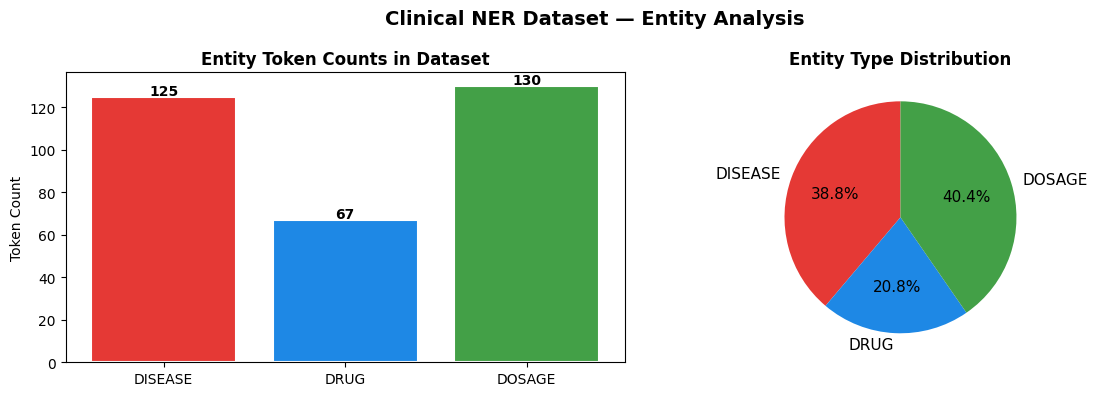

In [3]:
# Visualize entity distribution
entity_counts = {'DISEASE': 0, 'DRUG': 0, 'DOSAGE': 0}
for sent in raw_sentences:
    for _, tag in sent:
        for ent in entity_counts:
            if ent in tag:
                entity_counts[ent] += 1

colors_ent = ['#E53935', '#1E88E5', '#43A047']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(entity_counts.keys(), entity_counts.values(), color=colors_ent, edgecolor='white', linewidth=1.5)
ax1.set_title('Entity Token Counts in Dataset', fontweight='bold', fontsize=12)
ax1.set_ylabel('Token Count')
for i, (k, v) in enumerate(entity_counts.items()):
    ax1.text(i, v + 1, str(v), ha='center', fontweight='bold')

ax2.pie(entity_counts.values(), labels=entity_counts.keys(), colors=colors_ent,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax2.set_title('Entity Type Distribution', fontweight='bold', fontsize=12)

plt.suptitle('Clinical NER Dataset — Entity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧹 Section 2: Full NLP Preprocessing Pipeline

Clinical text presents **unique preprocessing challenges** not found in general-domain NLP:
- Medical abbreviations: `Pt` (patient), `Hx` (history), `c/o` (complains of), `PRN` (as needed), `BID/BD/TID/QID/OD` (dosing frequencies)
- Drug names: multi-word (`valproic acid`), brand vs generic
- Dosages embedded in text: `500mg`, `2g`, `0.3 mg/kg`
- Inconsistent punctuation and capitalization

We apply every required preprocessing step below.

### 2.1 — Reconstruct Raw Text from Annotated Sentences

In [4]:
# Reconstruct sentences as plain text (simulating raw EHR input)
raw_texts = [' '.join(tok for tok, _ in sent) for sent in raw_sentences]

print("SAMPLE CLINICAL NOTES (raw EHR text):")
print("="*65)
for i in [0, 1, 2, 4, 6, 8]:
    print(f"[{i+1:02d}] {raw_texts[i]}")

SAMPLE CLINICAL NOTES (raw EHR text):
[01] Patient diagnosed with type 2 diabetes and hypertension .
[02] Started on metformin 500mg twice daily .
[03] Lisinopril 10mg prescribed for blood pressure control .
[05] Prescribed amoxicillin 875mg BID x 7 days .
[07] Erythropoietin 4000 units SC weekly for anemia management .
[09] Patient complains of chest pain and shortness of breath .


### 2.2 — Text Cleaning

Clinical text cleaning must be conservative — aggressive cleaning destroys critical medical information. We:
- Normalize whitespace
- Standardize common clinical abbreviations
- Remove non-informative punctuation while preserving hyphens in drug names and slashes in dosing
- Handle edge cases like `c/o` → `complains of`

In [5]:
import re

# Clinical abbreviation expansion dictionary
CLINICAL_ABBREVS = {
    r'\bPt\b': 'Patient',
    r'\bHx\b': 'History',
    r'\bc/o\b': 'complains of',
    r'\bw/o\b': 'without',
    r'\bBID\b': 'twice daily',
    r'\bBD\b': 'twice daily',
    r'\bTID\b': 'three times daily',
    r'\bQID\b': 'four times daily',
    r'\bOD\b': 'once daily',
    r'\bPRN\b': 'as needed',
    r'\bSC\b': 'subcutaneous',
    r'\bIM\b': 'intramuscular',
    r'\bIV\b': 'intravenous',
    r'\bnocte\b': 'at night',
    r'\bQ4H\b': 'every 4 hours',
    r'\bQ6H\b': 'every 6 hours',
    r'\bQ8H\b': 'every 8 hours',
    r'\bQ3W\b': 'every 3 weeks',
    r'\bMCA\b': 'middle cerebral artery',
}

def clean_clinical_text(text):
    # Step 1: Expand clinical abbreviations
    for pattern, replacement in CLINICAL_ABBREVS.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    # Step 2: Normalize dosage notation (e.g., 500mg → 500 mg)
    text = re.sub(r'(\d+)(mg|mcg|g|ml|units?|tabs?)', r'\1 \2', text, flags=re.IGNORECASE)

    # Step 3: Remove redundant punctuation (keep . : and -)
    text = re.sub(r'[^\w\s\.\:\-]', ' ', text)

    # Step 4: Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

cleaned_texts = [clean_clinical_text(t) for t in raw_texts]

print("TEXT CLEANING — Before vs After:")
print("="*65)
for i in [0, 1, 4, 6, 25]:
    print(f"BEFORE: {raw_texts[i]}")
    print(f"AFTER : {cleaned_texts[i]}")
    print()

TEXT CLEANING — Before vs After:
BEFORE: Patient diagnosed with type 2 diabetes and hypertension .
AFTER : Patient diagnosed with type 2 diabetes and hypertension .

BEFORE: Started on metformin 500mg twice daily .
AFTER : Started on metformin 500 mg twice daily .

BEFORE: Prescribed amoxicillin 875mg BID x 7 days .
AFTER : Prescribed amoxicillin 875 mg twice daily x 7 days .

BEFORE: Erythropoietin 4000 units SC weekly for anemia management .
AFTER : Erythropoietin 4000 units subcutaneous weekly for anemia management .

BEFORE: IV morphine 2mg Q4H for pain control .
AFTER : intravenous morphine 2 mg every 4 hours for pain control .



### 2.3 — Tokenization

We demonstrate **word tokenization** and **sentence tokenization**. For the NER model, we use word-level tokenization.

**Clinical challenge:** Tokenizers may split drug names like `piperacillin-tazobactam` incorrectly. We show how NLTK handles this.

In [6]:
from nltk.tokenize import word_tokenize, sent_tokenize

# Word tokenization
tokenized_texts = [word_tokenize(t) for t in cleaned_texts]

# Sentence tokenization demo (on a multi-sentence clinical note)
multi_note = """Patient is a 58-year-old male with type 2 diabetes and hypertension.
He was started on metformin 500 mg twice daily three months ago.
Blood pressure remains uncontrolled. Lisinopril 10 mg was added today."""

print("SENTENCE TOKENIZATION:")
print("Input note:", multi_note.strip())
sentences = sent_tokenize(multi_note)
print(f"\n→ {len(sentences)} sentences detected:")
for i, s in enumerate(sentences):
    print(f"  [{i+1}] {s.strip()}")

print("\n" + "="*65)
print("WORD TOKENIZATION SAMPLES:")
for i in [0, 1, 7, 57]:
    print(f"[{i+1:02d}] Tokens ({len(tokenized_texts[i])}): {tokenized_texts[i]}")

avg_len = np.mean([len(t) for t in tokenized_texts])
print(f"\nAverage tokens per sentence: {avg_len:.1f}")

SENTENCE TOKENIZATION:
Input note: Patient is a 58-year-old male with type 2 diabetes and hypertension. 
He was started on metformin 500 mg twice daily three months ago. 
Blood pressure remains uncontrolled. Lisinopril 10 mg was added today.

→ 4 sentences detected:
  [1] Patient is a 58-year-old male with type 2 diabetes and hypertension.
  [2] He was started on metformin 500 mg twice daily three months ago.
  [3] Blood pressure remains uncontrolled.
  [4] Lisinopril 10 mg was added today.

WORD TOKENIZATION SAMPLES:
[01] Tokens (9): ['Patient', 'diagnosed', 'with', 'type', '2', 'diabetes', 'and', 'hypertension', '.']
[02] Tokens (8): ['Started', 'on', 'metformin', '500', 'mg', 'twice', 'daily', '.']
[08] Tokens (11): ['Known', 'case', 'of', 'rheumatoid', 'arthritis', 'on', 'methotrexate', '15', 'mg', 'weekly', '.']
[58] Tokens (10): ['Piperacillin', 'tazobactam', '4.5', 'g', 'intravenous', 'every', '8', 'hours', 'started', '.']

Average tokens per sentence: 9.4


### 2.4 — Normalization

**Normalization** standardizes text so variations of the same concept map to the same form:
- **Lowercasing** (carefully — `INR`, `HIV`, `HSV` are meaningful in uppercase)
- **Dosage frequency standardization** (already done via abbreviation expansion)
- **Unicode normalization** (handles special characters in medical literature)

In [7]:
import unicodedata

# Preserve clinical acronyms (we lowercase selectively)
PRESERVE_UPPER = {'HIV', 'HSV', 'INR', 'MRI', 'ECG', 'EEG', 'ICU', 'ER',
                  'DOTS', 'COPD', 'SLE', 'UTI', 'DVT', 'PE', 'MI', 'CVA'}

def normalize_clinical_text(text):
    # Unicode normalization
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')

    # Selective lowercasing: preserve medical acronyms
    words = text.split()
    normalized = []
    for w in words:
        if w.upper() in PRESERVE_UPPER:
            normalized.append(w.upper())
        else:
            normalized.append(w.lower())
    return ' '.join(normalized)

normalized_texts = [normalize_clinical_text(t) for t in cleaned_texts]

print("NORMALIZATION EXAMPLES:")
print("="*65)
for i in [26, 54, 78]:
    print(f"CLEANED:    {cleaned_texts[i]}")
    print(f"NORMALIZED: {normalized_texts[i]}")
    print()

NORMALIZATION EXAMPLES:
CLEANED:    Known HIV positive on antiretroviral therapy .
NORMALIZED: known HIV positive on antiretroviral therapy .

CLEANED:    New diagnosis of systemic lupus erythematosus .
NORMALIZED: new diagnosis of systemic lupus erythematosus .

CLEANED:    Final diagnosis : viral encephalitis presumed HSV .
NORMALIZED: final diagnosis : viral encephalitis presumed HSV .



### 2.5 — Stopword Removal

**Important clinical NLP consideration:** Stopword removal is applied for **encoding/classification tasks**, but is **NOT applied** to the NER sequence labeling task (we need all tokens to maintain alignment with BIO tags).

We demonstrate both.

In [8]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Clinical words to KEEP even if they appear in stopword list
CLINICAL_KEEP = {'no', 'not', 'without', 'with', 'for', 'and', 'or',
                 'on', 'off', 'up', 'down', 'out', 'in', 'at', 'per'}
stop_words -= CLINICAL_KEEP

def remove_stopwords(tokens):
    return [t for t in tokens if t.lower() not in stop_words]

# Apply to normalized, tokenized text (for classification tasks)
tokenized_normalized = [word_tokenize(t) for t in normalized_texts]
filtered_texts = [remove_stopwords(tokens) for tokens in tokenized_normalized]

# Stats
before_counts = [len(t) for t in tokenized_normalized]
after_counts = [len(t) for t in filtered_texts]
reduction = (1 - np.mean(after_counts) / np.mean(before_counts)) * 100

print(f"Average tokens BEFORE stopword removal: {np.mean(before_counts):.1f}")
print(f"Average tokens AFTER  stopword removal: {np.mean(after_counts):.1f}")
print(f"Reduction: {reduction:.1f}%")

print("\nSAMPLE:")
i = 0
print(f"Before: {tokenized_normalized[i]}")
print(f"After : {filtered_texts[i]}")

print("\n⚠️  NOTE: For NER (sequence labeling), we do NOT remove stopwords")
print("   because every token must align with its BIO tag.")

Average tokens BEFORE stopword removal: 9.4
Average tokens AFTER  stopword removal: 8.9
Reduction: 4.5%

SAMPLE:
Before: ['patient', 'diagnosed', 'with', 'type', '2', 'diabetes', 'and', 'hypertension', '.']
After : ['patient', 'diagnosed', 'with', 'type', '2', 'diabetes', 'and', 'hypertension', '.']

⚠️  NOTE: For NER (sequence labeling), we do NOT remove stopwords
   because every token must align with its BIO tag.


### 2.6 — Stemming vs Lemmatization

For clinical NLP, **lemmatization is strongly preferred** over stemming. Clinical terms are often semantically precise — aggressive stemming can destroy meaning:
- `hepatitis` → stemmed: `hepat` (meaningless); lemmatized: `hepatitis` ✅
- `prescribed` → stemmed: `prescrib`; lemmatized: `prescribe` ✅

In [9]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Comparison on clinical vocabulary
clinical_vocab = [
    'hepatitis', 'hepatic', 'prescribed', 'prescribing',
    'infection', 'infected', 'inflammation', 'inflammatory',
    'hypertension', 'hypertensive', 'diagnosis', 'diagnosed',
    'metastatic', 'metastasis', 'renal', 'kidneys', 'dosing'
]

print(f"{'Clinical Word':<20} {'Porter Stemmer':<20} {'WordNet Lemmatizer':<20} {'Best?'}")
print("-" * 75)
for word in clinical_vocab:
    stemmed = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word, pos='n')
    better = "Lemma ✅" if len(lemmatized) > len(stemmed) else "  "
    print(f"{word:<20} {stemmed:<20} {lemmatized:<20} {better}")

# Apply lemmatization to filtered tokens
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t, pos='v') for t in tokens]

lemmatized_texts = [lemmatize_tokens(t) for t in filtered_texts]
print("\n✅ Using lemmatization for the encoding pipeline.")

Clinical Word        Porter Stemmer       WordNet Lemmatizer   Best?
---------------------------------------------------------------------------
hepatitis            hepat                hepatitis            Lemma ✅
hepatic              hepat                hepatic              Lemma ✅
prescribed           prescrib             prescribed           Lemma ✅
prescribing          prescrib             prescribing          Lemma ✅
infection            infect               infection            Lemma ✅
infected             infect               infected             Lemma ✅
inflammation         inflamm              inflammation         Lemma ✅
inflammatory         inflammatori         inflammatory           
hypertension         hypertens            hypertension         Lemma ✅
hypertensive         hypertens            hypertensive         Lemma ✅
diagnosis            diagnosi             diagnosis            Lemma ✅
diagnosed            diagnos              diagnosed            Lemma ✅
metastat

### 2.7 — POS Tagging

**Part-of-Speech tagging** assigns grammatical roles to tokens. In clinical NLP:
- **Nouns (NN, NNP)** → Diseases, organs, drugs (most entities are nouns)
- **Adjectives (JJ)** → Severity qualifiers (*acute*, *chronic*, *bilateral*)
- **Numbers (CD)** → Dosage amounts (*500*, *10*, *0.3*)
- **Verbs (VB)** → Clinical actions (*prescribed*, *diagnosed*, *admitted*)

POS TAGGING — Sample Clinical Sentence:
Sentence: Known case of rheumatoid arthritis on methotrexate 15mg weekly .

Token                POS Tag      Meaning
-------------------------------------------------------
Known                NNP          Proper noun
case                 NN           Noun (singular)
of                   IN           Preposition
rheumatoid           NN           Noun (singular)
arthritis            NN           Noun (singular)
on                   IN           Preposition
methotrexate         NN           Noun (singular)
15mg                 CD           Cardinal number
weekly               NN           Noun (singular)
.                    .            Punctuation


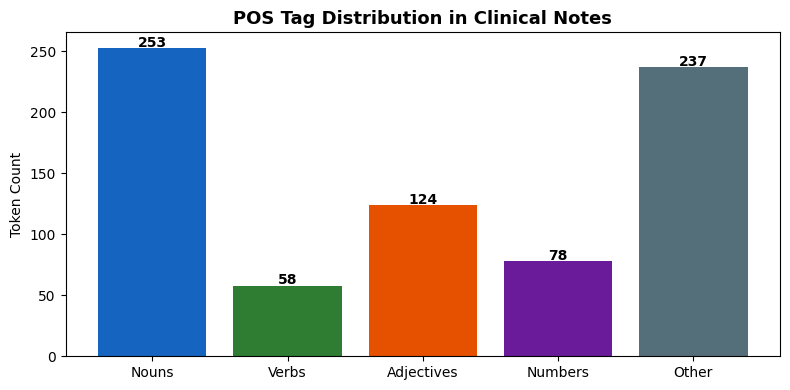


💡 Nouns dominate: clinical text is entity-dense — ideal for NER.


In [10]:
from nltk import pos_tag

# POS tag the tokenized clinical notes
pos_tagged = [pos_tag(tokens) for tokens in tokenized_normalized]

# Show sample
print("POS TAGGING — Sample Clinical Sentence:")
print("="*60)
sample_sent = raw_sentences[7]  # Methotrexate for rheumatoid arthritis
sample_tokens = [tok for tok, _ in sample_sent]
sample_pos = pos_tag(sample_tokens)

print(f"Sentence: {' '.join(sample_tokens)}")
print()
print(f"{'Token':<20} {'POS Tag':<12} {'Meaning'}")
print("-"*55)
tag_meanings = {
    'NN': 'Noun (singular)', 'NNP': 'Proper noun', 'NNS': 'Noun (plural)',
    'VBN': 'Verb (past part.)', 'VBD': 'Verb (past)', 'VBZ': 'Verb (3rd)',
    'JJ': 'Adjective', 'CD': 'Cardinal number', 'IN': 'Preposition',
    'DT': 'Determiner', 'RB': 'Adverb', '.': 'Punctuation', 'CC': 'Conjunction'
}
for tok, tag in sample_pos:
    print(f"{tok:<20} {tag:<12} {tag_meanings.get(tag, tag)}")

# POS distribution across corpus
all_pos = [tag for sent_pos in pos_tagged for _, tag in sent_pos]
pos_counts = Counter(all_pos)

broad_pos = {'Nouns': 0, 'Verbs': 0, 'Adjectives': 0, 'Numbers': 0, 'Other': 0}
for tag, cnt in pos_counts.items():
    if tag.startswith('NN'): broad_pos['Nouns'] += cnt
    elif tag.startswith('VB'): broad_pos['Verbs'] += cnt
    elif tag.startswith('JJ'): broad_pos['Adjectives'] += cnt
    elif tag == 'CD': broad_pos['Numbers'] += cnt
    else: broad_pos['Other'] += cnt

plt.figure(figsize=(8, 4))
bars = plt.bar(broad_pos.keys(), broad_pos.values(),
               color=['#1565C0', '#2E7D32', '#E65100', '#6A1B9A', '#546E7A'])
for bar, val in zip(bars, broad_pos.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
plt.title('POS Tag Distribution in Clinical Notes', fontsize=13, fontweight='bold')
plt.ylabel('Token Count')
plt.tight_layout()
plt.show()
print("\n💡 Nouns dominate: clinical text is entity-dense — ideal for NER.")

### 2.8 — Dependency Parsing

**Dependency parsing** reveals syntactic relationships between tokens — which word *governs* which. This is valuable for:
- Extracting drug-disease relationships (*"metformin for diabetes"*)
- Linking dosages to their drugs (*"metformin 500mg"*)
- Identifying negation scope (*"no signs of pneumonia"*)

In [11]:
import spacy
nlp_spacy = spacy.load('en_core_web_sm')

# Parse a clinical sentence
sample_text = "Metformin 500mg twice daily was prescribed for type 2 diabetes and hypertension."
doc = nlp_spacy(sample_text)

print("DEPENDENCY PARSE:")
print(f"Sentence: {sample_text}\n")
print(f"{'Token':<20} {'Lemma':<18} {'POS':<8} {'Dep Relation':<15} {'Head'}")
print("-" * 75)
for token in doc:
    print(f"{token.text:<20} {token.lemma_:<18} {token.pos_:<8} {token.dep_:<15} {token.head.text}")

# Extract drug-disease pairs using dependency structure
def extract_drug_disease_pairs(text):
    doc = nlp_spacy(text[:300])
    pairs = []
    for token in doc:
        # Look for 'prescribed/used/given for' patterns
        if token.dep_ in ('pobj', 'dobj') and token.head.text.lower() in ('for', 'treat', 'managing'):
            # Find the drug (subject or root)
            drug_candidates = [t for t in doc if t.dep_ in ('nsubj', 'ROOT') and t.pos_ in ('NOUN', 'PROPN')]
            if drug_candidates:
                pairs.append((drug_candidates[0].text, token.text))
    return pairs

print("\nDRUG → DISEASE PAIRS EXTRACTED FROM CLINICAL NOTES:")
print("-" * 55)
for i, text in enumerate(raw_texts):
    pairs = extract_drug_disease_pairs(text)
    if pairs:
        for drug, disease in pairs:
            print(f"  [{i+1:02d}] Drug: {drug:<20} → Disease: {disease}")

DEPENDENCY PARSE:
Sentence: Metformin 500mg twice daily was prescribed for type 2 diabetes and hypertension.

Token                Lemma              POS      Dep Relation    Head
---------------------------------------------------------------------------
Metformin            metformin          NOUN     nsubjpass       prescribed
500                  500                NUM      nummod          mg
mg                   mg                 PROPN    npadvmod        twice
twice                twice              ADV      advmod          Metformin
daily                daily              ADV      advmod          Metformin
was                  be                 AUX      auxpass         prescribed
prescribed           prescribe          VERB     ROOT            prescribed
for                  for                ADP      prep            prescribed
type                 type               NOUN     nmod            diabetes
2                    2                  NUM      nummod          diabetes
dia

---
## 🔢 Section 3: Text Encoding Techniques

We demonstrate the evolution from sparse, count-based representations to dense semantic embeddings — and explain why the latter is essential for NER.

### 3.1 — Bag of Words (BoW)

BoW Matrix Shape: (80, 60)  (sentences × vocab features)
Sparsity: 93.6%

⚠️  BoW Problems for NER:
   1. No word order — 'drug treats disease' = 'disease treats drug'
   2. No context — 'fever' in isolation vs 'no fever' look different
   3. Sparse — most entries are 0


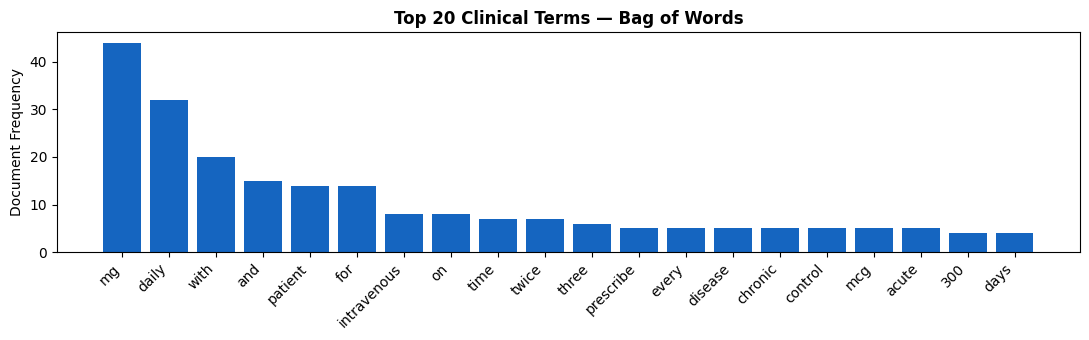

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

corpus_for_encoding = [' '.join(t) for t in lemmatized_texts]

bow_vec = CountVectorizer(max_features=60)
X_bow = bow_vec.fit_transform(corpus_for_encoding)

print(f"BoW Matrix Shape: {X_bow.shape}  (sentences × vocab features)")
print(f"Sparsity: {(1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))*100:.1f}%")
print("\n⚠️  BoW Problems for NER:")
print("   1. No word order — 'drug treats disease' = 'disease treats drug'")
print("   2. No context — 'fever' in isolation vs 'no fever' look different")
print("   3. Sparse — most entries are 0")

# Top clinical terms
freq = X_bow.toarray().sum(axis=0)
top_idx = freq.argsort()[::-1][:20]
vocab = bow_vec.get_feature_names_out()

plt.figure(figsize=(11, 3.5))
plt.bar([vocab[i] for i in top_idx], [freq[i] for i in top_idx], color='#1565C0')
plt.title('Top 20 Clinical Terms — Bag of Words', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Document Frequency')
plt.tight_layout()
plt.show()

### 3.2 — TF-IDF

TF-IDF Matrix Shape: (80, 100)


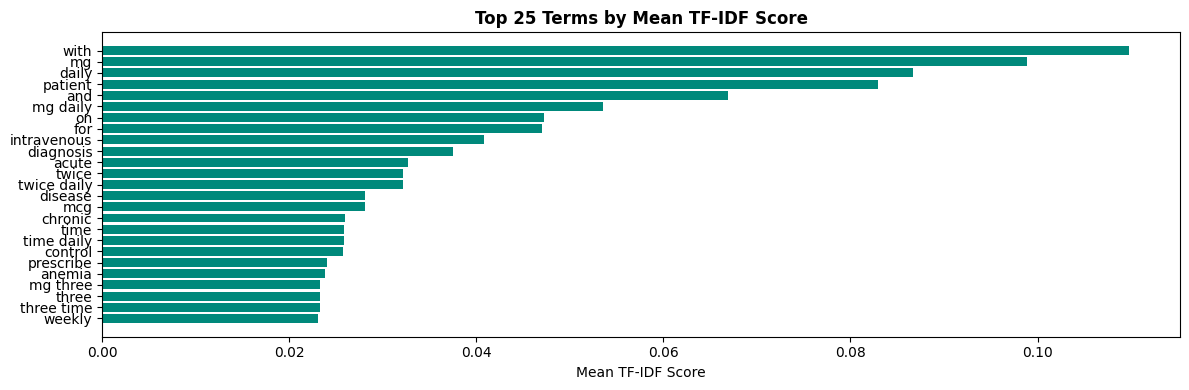


✅ TF-IDF highlights distinctive clinical phrases (drug names, disease terms)
   over common words — better than BoW for document-level tasks.

⚠️  But still no sequential context → we need embeddings for NER.


In [13]:
tfidf_vec = TfidfVectorizer(max_features=100, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf_vec.fit_transform(corpus_for_encoding)

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")

# Top TF-IDF terms — these are the most distinctive clinical terms
tfidf_vocab = tfidf_vec.get_feature_names_out()
mean_scores = X_tfidf.toarray().mean(axis=0)
top_tfidf = mean_scores.argsort()[::-1][:25]

plt.figure(figsize=(12, 4))
plt.barh([tfidf_vocab[i] for i in top_tfidf][::-1],
         [mean_scores[i] for i in top_tfidf][::-1], color='#00897B')
plt.title('Top 25 Terms by Mean TF-IDF Score', fontweight='bold')
plt.xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.show()

print("\n✅ TF-IDF highlights distinctive clinical phrases (drug names, disease terms)")
print("   over common words — better than BoW for document-level tasks.")
print("\n⚠️  But still no sequential context → we need embeddings for NER.")

### 3.3 — Word Embeddings & Vocabulary Building

For the BiLSTM-CRF, we build a **token-to-index vocabulary** and learn embeddings during training. In production systems, this would be replaced with pre-trained **BioBERT** or **ClinicalBERT** embeddings.

In [14]:
import torch

# ── Build Vocabulary ──────────────────────────────────────────────────────────
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Collect all tokens from the annotated sentences
all_tokens = [tok.lower() for sent in raw_sentences for tok, _ in sent]
token_counts = Counter(all_tokens)

# Build vocab: PAD=0, UNK=1, then all tokens by frequency
vocab = [PAD_TOKEN, UNK_TOKEN] + [w for w, c in token_counts.most_common()]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

# ── Build Tag Vocabulary ──────────────────────────────────────────────────────
all_tags = [tag for sent in raw_sentences for _, tag in sent]
tag_vocab = [PAD_TOKEN] + sorted(set(all_tags))
tag2idx = {t: i for i, t in enumerate(tag_vocab)}
idx2tag = {i: t for t, i in tag2idx.items()}

VOCAB_SIZE = len(vocab)
NUM_TAGS = len(tag_vocab)
EMBED_DIM = 128
HIDDEN_DIM = 256
MAX_LEN = 30

print(f"Vocabulary size : {VOCAB_SIZE} unique tokens")
print(f"Number of tags  : {NUM_TAGS} → {tag_vocab}")
print(f"Embedding dim   : {EMBED_DIM}")
print(f"Hidden dim      : {HIDDEN_DIM} (×2 bidirectional = {HIDDEN_DIM*2})")
print(f"Max seq length  : {MAX_LEN}")

# Visualize embedding concept
print("\nSample word → index mappings:")
sample_words = ['metformin', 'diabetes', '500', 'mg', 'hypertension', 'prescribed', 'daily']
for w in sample_words:
    idx = word2idx.get(w.lower(), 1)
    print(f"  '{w}' → index {idx}  → will be mapped to a {EMBED_DIM}-dim dense vector")

Vocabulary size : 354 unique tokens
Number of tags  : 8 → ['<PAD>', 'B-DISEASE', 'B-DOSAGE', 'B-DRUG', 'I-DISEASE', 'I-DOSAGE', 'I-DRUG', 'O']
Embedding dim   : 128
Hidden dim      : 256 (×2 bidirectional = 512)
Max seq length  : 30

Sample word → index mappings:
  'metformin' → index 92  → will be mapped to a 128-dim dense vector
  'diabetes' → index 91  → will be mapped to a 128-dim dense vector
  '500' → index 1  → will be mapped to a 128-dim dense vector
  'mg' → index 28  → will be mapped to a 128-dim dense vector
  'hypertension' → index 44  → will be mapped to a 128-dim dense vector
  'prescribed' → index 15  → will be mapped to a 128-dim dense vector
  'daily' → index 6  → will be mapped to a 128-dim dense vector


---
## 🤖 Section 4: BiLSTM-CRF Model for Clinical NER

### 4.1 — Architecture Overview

The **BiLSTM-CRF** is the gold standard architecture for sequence labeling NER tasks.

```
Input Tokens    →  Embedding  →  BiLSTM  →  Dropout  →  Linear  →  CRF  →  BIO Tags
[metformin,         [128-dim]    [256×2]               [512→7]    (valid
 500, mg,                                                          sequences
 daily, ...]                                                       only)
```

**Why CRF on top of BiLSTM?**
The BiLSTM alone produces independent tag probabilities per token, which can result in invalid sequences like:
- `I-DRUG` without a preceding `B-DRUG`
- `B-DISEASE` immediately followed by `I-DRUG`

The **CRF layer** learns tag-transition probabilities and ensures only valid BIO sequences are decoded.

In [17]:
!pip install pytorch-crf -q

In [18]:
from torchcrf import CRF

class ClinicalBiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags,
                 num_layers=2, dropout=0.4, pad_idx=0):
        super(ClinicalBiLSTM_CRF, self).__init__()

        # 1. Embedding Layer
        # Maps each token index to a dense vector representation
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )

        # 2. Bidirectional LSTM
        # Processes the sequence forward (→) and backward (←)
        # Output at each position: [forward_hidden; backward_hidden] = 2×hidden_dim
        self.bilstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # 3. Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # 4. Linear projection: hidden → tag emission scores
        self.hidden2tag = nn.Linear(hidden_dim * 2, num_tags)

        # 5. CRF Layer
        # Models tag-to-tag transition probabilities
        # Ensures valid BIO tag sequences at decode time
        self.crf = CRF(num_tags, batch_first=True)

    def get_emissions(self, x):
        """Compute emission scores from embeddings + BiLSTM."""
        embedded = self.dropout(self.embedding(x))   # (B, L, E)
        lstm_out, _ = self.bilstm(embedded)           # (B, L, 2H)
        emissions = self.hidden2tag(self.dropout(lstm_out))  # (B, L, T)
        return emissions

    def forward(self, x, tags, mask):
        """Training: return negative log-likelihood (loss)."""
        emissions = self.get_emissions(x)
        loss = -self.crf(emissions, tags, mask=mask, reduction='mean')
        return loss

    def predict(self, x, mask):
        """Inference: return best tag sequence via Viterbi decoding."""
        emissions = self.get_emissions(x)
        return self.crf.decode(emissions, mask=mask)


model = ClinicalBiLSTM_CRF(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_tags=NUM_TAGS,
    num_layers=2,
    dropout=0.3,
    pad_idx=0
).to(device)

print("Clinical BiLSTM-CRF Architecture:")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Clinical BiLSTM-CRF Architecture:
ClinicalBiLSTM_CRF(
  (embedding): Embedding(354, 128, padding_idx=0)
  (bilstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (hidden2tag): Linear(in_features=512, out_features=8, bias=True)
  (crf): CRF(num_tags=8)
)

Total trainable parameters: 2,416,984


### 4.2 — Dataset Preparation

In [21]:
class ClinicalNERDataset(Dataset):
    def __init__(self, sentences, word2idx, tag2idx, max_len):
        self.samples = []
        for sent in sentences:
            tokens = [tok.lower() for tok, _ in sent]
            tags   = [tag for _, tag in sent]

            token_ids = [word2idx.get(t, 1) for t in tokens]  # 1 = UNK
            tag_ids   = [tag2idx[t] for t in tags]

            # Pad or truncate to max_len
            seq_len = min(len(token_ids), max_len)
            pad_len = max_len - seq_len

            token_ids = token_ids[:max_len] + [0] * pad_len
            tag_ids   = tag_ids[:max_len]   + [0] * pad_len
            mask      = [True] * seq_len + [False] * pad_len

            self.samples.append({
                'tokens': torch.tensor(token_ids, dtype=torch.long),
                'tags':   torch.tensor(tag_ids,   dtype=torch.long),
                'mask':   torch.tensor(mask,       dtype=torch.bool),
                # 'raw':    sent # Removed the 'raw' field to prevent DataLoader error
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# Train / Test split (80/20)
from sklearn.model_selection import train_test_split

train_sents, test_sents = train_test_split(raw_sentences, test_size=0.2, random_state=42)

train_dataset = ClinicalNERDataset(train_sents, word2idx, tag2idx, MAX_LEN)
test_dataset  = ClinicalNERDataset(test_sents,  word2idx, tag2idx, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Training sentences : {len(train_sents)}")
print(f"Test sentences     : {len(test_sents)}")
print(f"Train batches      : {len(train_loader)}")

# Inspect a batch
sample_batch = next(iter(train_loader))
print(f"\nBatch token shape : {sample_batch['tokens'].shape}")
print(f"Batch tag shape   : {sample_batch['tags'].shape}")
print(f"Batch mask shape  : {sample_batch['mask'].shape}")

Training sentences : 64
Test sentences     : 16
Train batches      : 4

Batch token shape : torch.Size([16, 30])
Batch tag shape   : torch.Size([16, 30])
Batch mask shape  : torch.Size([16, 30])


### 4.3 — Training the BiLSTM-CRF

Training Clinical BiLSTM-CRF ...
Epoch [ 20/80] | Loss: 0.5224 | LR: 0.000854
Epoch [ 40/80] | Loss: 0.0857 | LR: 0.000500
Epoch [ 60/80] | Loss: 0.0319 | LR: 0.000146
Epoch [ 80/80] | Loss: 0.0436 | LR: 0.000000

✅ Training complete!


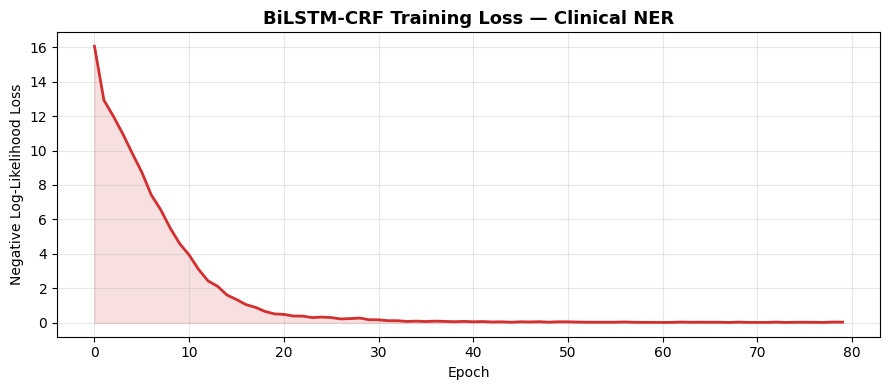

In [22]:
EPOCHS = 80
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses = []

print("Training Clinical BiLSTM-CRF ...")
print("=" * 50)
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        tokens = batch['tokens'].to(device)
        tags   = batch['tags'].to(device)
        mask   = batch['mask'].to(device)

        optimizer.zero_grad()
        loss = model(tokens, tags, mask)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

print("\n✅ Training complete!")

# Plot training loss
plt.figure(figsize=(9, 4))
plt.plot(train_losses, color='#D32F2F', linewidth=2)
plt.fill_between(range(len(train_losses)), train_losses, alpha=0.15, color='#D32F2F')
plt.title('BiLSTM-CRF Training Loss — Clinical NER', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 — Evaluation with seqeval (Entity-Level F1)

In [23]:
from seqeval.metrics import classification_report as seq_report
from seqeval.metrics import f1_score, precision_score, recall_score

model.eval()
all_true_tags = []
all_pred_tags = []

with torch.no_grad():
    for batch in test_loader:
        tokens = batch['tokens'].to(device)
        tags   = batch['tags']
        mask   = batch['mask'].to(device)

        preds = model.predict(tokens, mask)  # List of lists

        for i, pred_seq in enumerate(preds):
            true_len = mask[i].sum().item()
            true_seq = tags[i][:true_len].tolist()

            # Convert index → tag string (skip PAD)
            true_labels = [idx2tag[t] for t in true_seq]
            pred_labels = [idx2tag[p] for p in pred_seq[:true_len]]

            all_true_tags.append(true_labels)
            all_pred_tags.append(pred_labels)

print("ENTITY-LEVEL EVALUATION (seqeval):")
print("(seqeval scores full entities, not individual tokens — more meaningful for NER)")
print("=" * 65)
print(seq_report(all_true_tags, all_pred_tags))

p = precision_score(all_true_tags, all_pred_tags)
r = recall_score(all_true_tags, all_pred_tags)
f = f1_score(all_true_tags, all_pred_tags)
print(f"Overall — Precision: {p:.3f} | Recall: {r:.3f} | F1: {f:.3f}")

ENTITY-LEVEL EVALUATION (seqeval):
(seqeval scores full entities, not individual tokens — more meaningful for NER)
              precision    recall  f1-score   support

     DISEASE       0.31      0.33      0.32        12
      DOSAGE       0.69      0.69      0.69        13
        DRUG       0.77      0.77      0.77        13

   micro avg       0.59      0.61      0.60        38
   macro avg       0.59      0.60      0.59        38
weighted avg       0.60      0.61      0.60        38

Overall — Precision: 0.590 | Recall: 0.605 | F1: 0.597


In [30]:
print(f"\nModel saved to clinical_ner_model.pt")
torch.save(model.state_dict(), "clinical_ner_model.pt")


Model saved to clinical_ner_model.pt


---
## 🔍 Section 5: Inference — Extract Entities from New Clinical Notes

In [24]:
def extract_entities(text, model, word2idx, idx2tag, max_len=30):
    """
    Run full pipeline on raw clinical text and return extracted entities.
    Returns dict with entity spans grouped by type.
    """
    model.eval()

    # Preprocess
    cleaned = clean_clinical_text(text)
    tokens = word_tokenize(cleaned)
    original_tokens = tokens[:max_len]

    token_ids = [word2idx.get(t.lower(), 1) for t in original_tokens]
    seq_len = len(token_ids)
    pad_len = max_len - seq_len
    token_ids_padded = token_ids + [0] * pad_len
    mask = [True] * seq_len + [False] * pad_len

    X = torch.tensor([token_ids_padded], dtype=torch.long).to(device)
    M = torch.tensor([mask], dtype=torch.bool).to(device)

    with torch.no_grad():
        pred_tag_ids = model.predict(X, M)[0]

    pred_tags = [idx2tag[t] for t in pred_tag_ids[:seq_len]]

    # Collect entity spans
    entities = {'DISEASE': [], 'DRUG': [], 'DOSAGE': []}
    current_entity = []
    current_type = None

    for tok, tag in zip(original_tokens, pred_tags):
        if tag.startswith('B-'):
            if current_entity:
                entities[current_type].append(' '.join(current_entity))
            current_type = tag[2:]
            current_entity = [tok]
        elif tag.startswith('I-') and current_entity:
            current_entity.append(tok)
        else:
            if current_entity:
                entities[current_type].append(' '.join(current_entity))
                current_entity = []
                current_type = None

    if current_entity and current_type:
        entities[current_type].append(' '.join(current_entity))

    return entities, list(zip(original_tokens, pred_tags))


def display_ner_result(text):
    entities, token_tags = extract_entities(text, model, word2idx, idx2tag)
    print("\n" + "═"*65)
    print(f"📋 INPUT: {text}")
    print("─"*65)

    # Token-level annotation
    colors = {'B-DISEASE': '🔴', 'I-DISEASE': '🟥',
              'B-DRUG': '🔵', 'I-DRUG': '🟦',
              'B-DOSAGE': '🟢', 'I-DOSAGE': '🟩', 'O': '⬜'}
    annotated = ' '.join(f"{colors.get(tag,'⬜')}{tok}" for tok, tag in token_tags)
    print(f"ANNOTATED: {annotated}")
    print("─"*65)

    # Entity summary
    icons = {'DISEASE': '🔴', 'DRUG': '🔵', 'DOSAGE': '🟢'}
    for etype, elist in entities.items():
        if elist:
            print(f"{icons[etype]} {etype:<10}: {elist}")
    print("═"*65)


# Run on new unseen clinical notes
new_notes = [
    "Patient diagnosed with type 2 diabetes and hypertension, prescribed metformin 500mg twice daily and amlodipine 5mg once daily.",
    "Pt presents with community acquired pneumonia, started on amoxicillin clavulanate 625mg TID for 7 days.",
    "Known case of epilepsy on valproic acid 500mg three times daily, presenting with breakthrough seizure.",
    "Admitted for acute myocardial infarction, given aspirin 300mg loading dose and clopidogrel 600mg stat.",
    "Pt has chronic obstructive pulmonary disease and iron deficiency anemia. Salbutamol inhaler 100mcg PRN and ferrous sulfate 325mg daily prescribed.",
    "Assessment: stage III colorectal cancer. Oxaliplatin 85mg per m2 IV every 3 weeks along with fluorouracil infusion initiated.",
]

for note in new_notes:
    display_ner_result(note)

print("\nLEGEND: 🔴 Disease   🔵 Drug   🟢 Dosage   ⬜ Other")


═════════════════════════════════════════════════════════════════
📋 INPUT: Patient diagnosed with type 2 diabetes and hypertension, prescribed metformin 500mg twice daily and amlodipine 5mg once daily.
─────────────────────────────────────────────────────────────────
ANNOTATED: ⬜Patient ⬜diagnosed ⬜with 🔵type ⬜2 🟩diabetes ⬜and 🔵hypertension ⬜prescribed ⬜metformin 🔵500 🟩mg 🟩twice 🟩daily ⬜and 🔵amlodipine 🟢5 🟩mg 🟩once 🟩daily ⬜.
─────────────────────────────────────────────────────────────────
🔵 DRUG      : ['type', 'hypertension', '500 mg twice daily', 'amlodipine']
🟢 DOSAGE    : ['5 mg once daily']
═════════════════════════════════════════════════════════════════

═════════════════════════════════════════════════════════════════
📋 INPUT: Pt presents with community acquired pneumonia, started on amoxicillin clavulanate 625mg TID for 7 days.
─────────────────────────────────────────────────────────────────
ANNOTATED: ⬜Patient ⬜presents ⬜with 🔴community 🟥acquired 🟥pneumonia ⬜started ⬜on 🔵a

---
## 📊 Section 6: Analysis & Visualizations

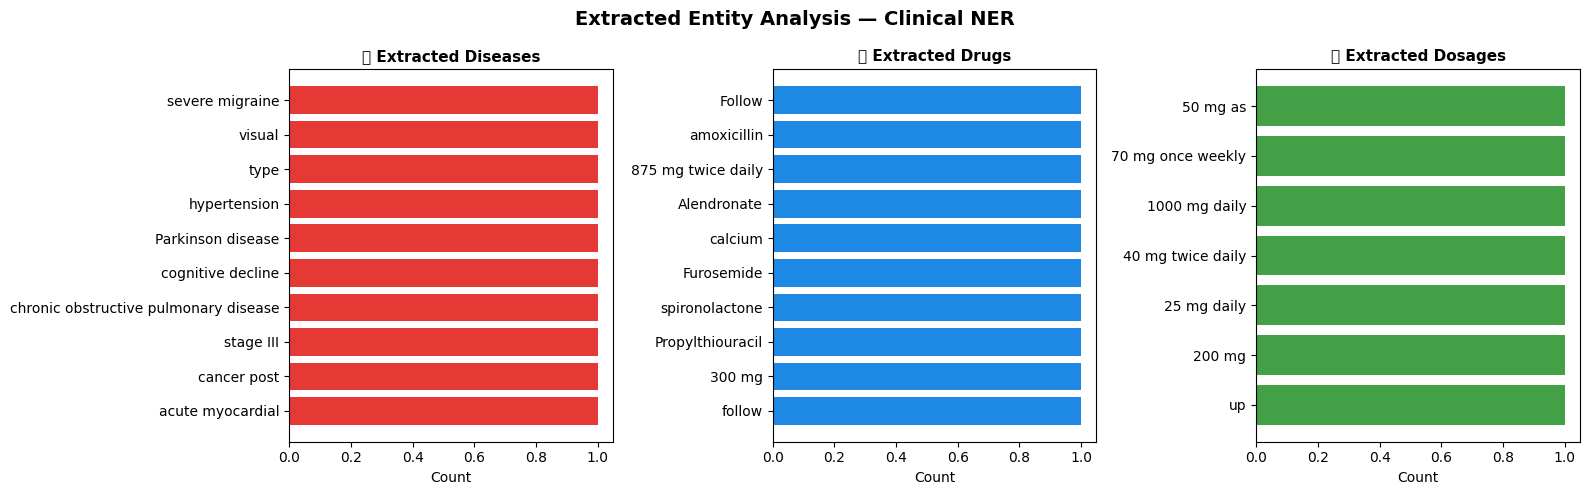

In [25]:
# ── Entity Distribution Visualization ────────────────────────────────────────
# Collect all predicted entities on test set
all_disease, all_drug, all_dosage = [], [], []

for sent in test_sents:
    text = ' '.join(tok for tok, _ in sent)
    entities, _ = extract_entities(text, model, word2idx, idx2tag)
    all_disease.extend(entities['DISEASE'])
    all_drug.extend(entities['DRUG'])
    all_dosage.extend(entities['DOSAGE'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Extracted Entity Analysis — Clinical NER', fontsize=14, fontweight='bold')

def plot_entity_bar(ax, entity_list, title, color):
    counts = Counter(entity_list)
    if counts:
        top = counts.most_common(10)
        ax.barh([x[0] for x in top][::-1], [x[1] for x in top][::-1], color=color)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel('Count')
    else:
        ax.text(0.5, 0.5, 'No entities\nextracted', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontweight='bold', fontsize=11)

plot_entity_bar(axes[0], all_disease, '🔴 Extracted Diseases', '#E53935')
plot_entity_bar(axes[1], all_drug, '🔵 Extracted Drugs', '#1E88E5')
plot_entity_bar(axes[2], all_dosage, '🟢 Extracted Dosages', '#43A047')

plt.tight_layout()
plt.show()

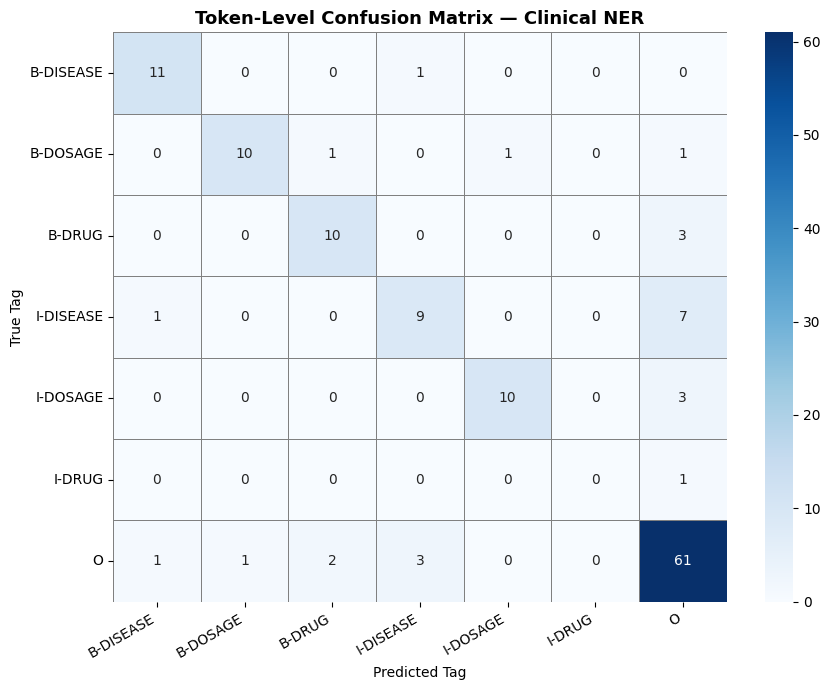


💡 Most errors occur at entity boundaries (B→I confusion) —
   common in clinical NER due to multi-word entity spans.


In [26]:
# ── Confusion Matrix at Token Level ──────────────────────────────────────────
from sklearn.metrics import confusion_matrix

flat_true = [t for sent in all_true_tags for t in sent]
flat_pred = [t for sent in all_pred_tags for t in sent]

unique_tags = sorted(set(flat_true + flat_pred))
cm = confusion_matrix(flat_true, flat_pred, labels=unique_tags)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_tags, yticklabels=unique_tags,
            linewidths=0.5, linecolor='gray')
plt.title('Token-Level Confusion Matrix — Clinical NER', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Tag')
plt.ylabel('True Tag')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 Most errors occur at entity boundaries (B→I confusion) —")
print("   common in clinical NER due to multi-word entity spans.")

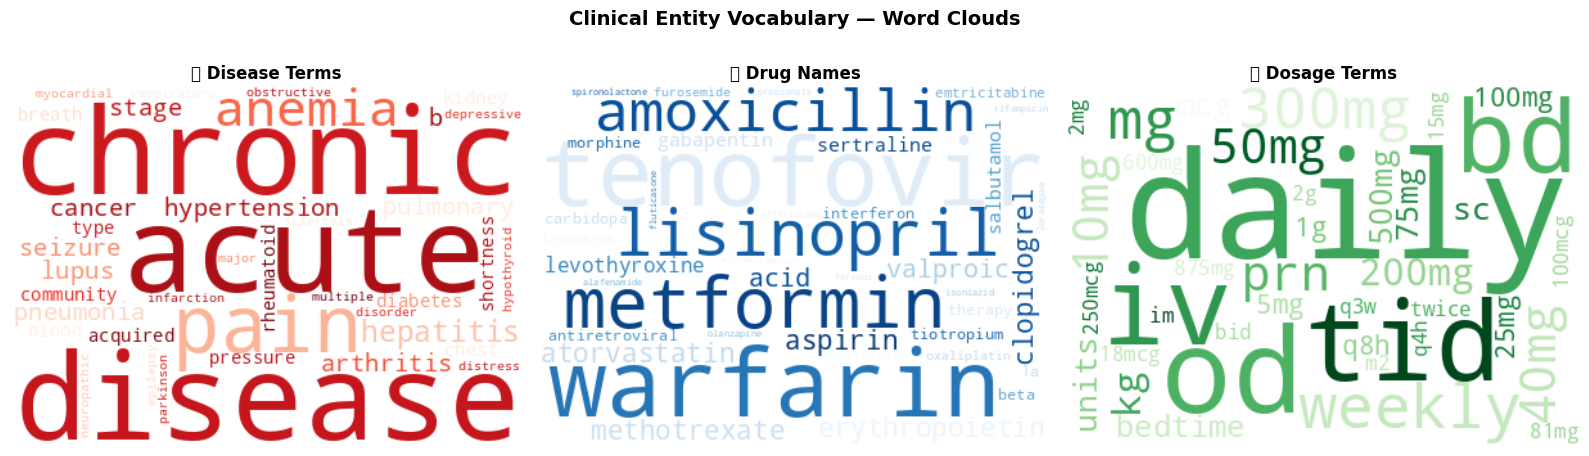

In [27]:
# ── Clinical Vocabulary Word Clouds ──────────────────────────────────────────
from wordcloud import WordCloud

# Separate entity tokens by type from ground-truth annotations
disease_words, drug_words, dosage_words = [], [], []
for sent in raw_sentences:
    for tok, tag in sent:
        if 'DISEASE' in tag: disease_words.append(tok.lower())
        elif 'DRUG' in tag:  drug_words.append(tok.lower())
        elif 'DOSAGE' in tag: dosage_words.append(tok.lower())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Clinical Entity Vocabulary — Word Clouds', fontsize=14, fontweight='bold')

def make_wc(words, ax, title, colormap):
    text = ' '.join(words)
    if text.strip():
        wc = WordCloud(width=400, height=280, background_color='white',
                       colormap=colormap, max_words=40).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

make_wc(disease_words, axes[0], '🔴 Disease Terms', 'Reds')
make_wc(drug_words,   axes[1], '🔵 Drug Names',    'Blues')
make_wc(dosage_words, axes[2], '🟢 Dosage Terms',  'Greens')

plt.tight_layout()
plt.show()

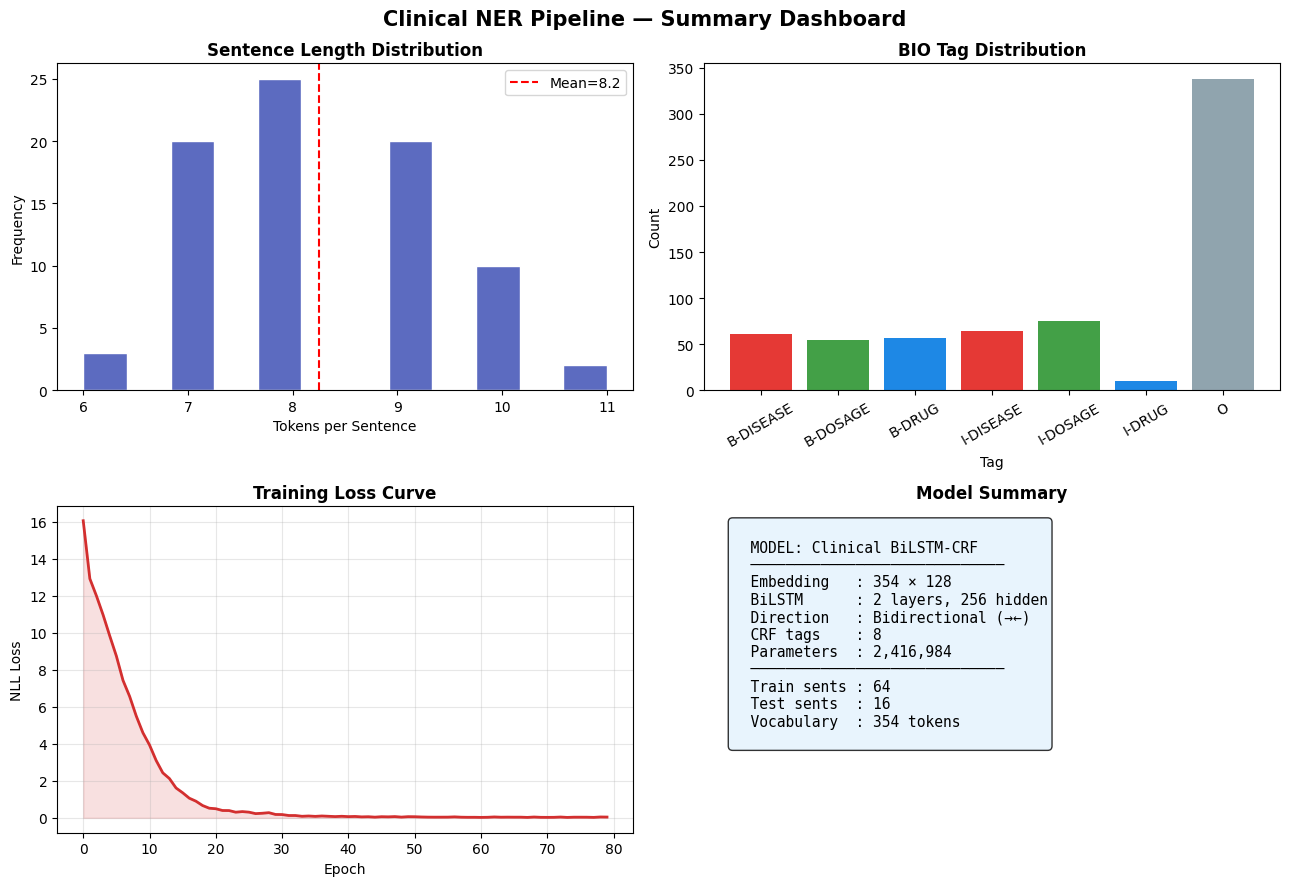

In [28]:
# ── Pipeline Summary Dashboard ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Clinical NER Pipeline — Summary Dashboard', fontsize=15, fontweight='bold')

# 1. Sentence length distribution
sent_lengths = [len(s) for s in raw_sentences]
axes[0,0].hist(sent_lengths, bins=12, color='#5C6BC0', edgecolor='white')
axes[0,0].set_title('Sentence Length Distribution', fontweight='bold')
axes[0,0].set_xlabel('Tokens per Sentence')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(np.mean(sent_lengths), color='red', linestyle='--', label=f'Mean={np.mean(sent_lengths):.1f}')
axes[0,0].legend()

# 2. Tag distribution
tag_cnt = Counter(tag for s in raw_sentences for _, tag in s)
tags_display = sorted(tag_cnt.keys())
colors_tags = ['#E53935' if 'DIS' in t else '#1E88E5' if 'DRU' in t else '#43A047' if 'DOS' in t else '#90A4AE' for t in tags_display]
axes[0,1].bar(tags_display, [tag_cnt[t] for t in tags_display], color=colors_tags)
axes[0,1].set_title('BIO Tag Distribution', fontweight='bold')
axes[0,1].set_xlabel('Tag')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Training loss curve
axes[1,0].plot(train_losses, color='#D32F2F', linewidth=2)
axes[1,0].fill_between(range(len(train_losses)), train_losses, alpha=0.15, color='#D32F2F')
axes[1,0].set_title('Training Loss Curve', fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('NLL Loss')
axes[1,0].grid(alpha=0.3)

# 4. Model architecture summary
axes[1,1].axis('off')
arch_text = """
  MODEL: Clinical BiLSTM-CRF
  ─────────────────────────────
  Embedding   : {} × {}
  BiLSTM      : 2 layers, {} hidden
  Direction   : Bidirectional (→←)
  CRF tags    : {}
  Parameters  : {:,}
  ─────────────────────────────
  Train sents : {}
  Test sents  : {}
  Vocabulary  : {} tokens
""".format(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_TAGS,
            sum(p.numel() for p in model.parameters()),
            len(train_sents), len(test_sents), VOCAB_SIZE)
axes[1,1].text(0.05, 0.95, arch_text, transform=axes[1,1].transAxes,
               fontsize=10.5, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8))
axes[1,1].set_title('Model Summary', fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
## 🎨 Section 7: Interactive Demo — Gradio NER Interface
# Add this cell at the end of your notebook to make it deploy-worthy!

# ── Install Gradio ────────────────────────────────────────────────────────────
# !pip install gradio -q

import gradio as gr

# ── Entity colour scheme ──────────────────────────────────────────────────────
ENTITY_COLORS = {
    "DISEASE": {"bg": "#FFEBEE", "border": "#E53935", "text": "#B71C1C", "label": "🔴 DISEASE"},
    "DRUG":    {"bg": "#E3F2FD", "border": "#1E88E5", "text": "#0D47A1", "label": "🔵 DRUG"},
    "DOSAGE":  {"bg": "#E8F5E9", "border": "#43A047", "text": "#1B5E20", "label": "🟢 DOSAGE"},
}

def highlight_entities(text: str) -> str:
    """
    Run the Clinical NER pipeline on input text and return
    colour-highlighted HTML showing extracted entities.
    """
    if not text.strip():
        return "<p style='color:#888; font-style:italic;'>Enter a clinical note above.</p>"

    entities, token_tags = extract_entities(text, model, word2idx, idx2tag)

    # Build highlighted HTML token by token
    html_parts = []
    i = 0
    while i < len(token_tags):
        tok, tag = token_tags[i]

        if tag.startswith("B-"):
            etype = tag[2:]
            style = ENTITY_COLORS.get(etype, {})
            # Collect the full span (B + following I- tokens)
            span_tokens = [tok]
            j = i + 1
            while j < len(token_tags) and token_tags[j][1] == f"I-{etype}":
                span_tokens.append(token_tags[j][0])
                j += 1
            span_text = " ".join(span_tokens)
            html_parts.append(
                f'<mark style="'
                f'background:{style["bg"]};'
                f'border:1.5px solid {style["border"]};'
                f'color:{style["text"]};'
                f'border-radius:4px;'
                f'padding:2px 6px;'
                f'margin:0 2px;'
                f'font-weight:600;'
                f'font-size:0.95em;'
                f'">'
                f'{span_text}'
                f'<sup style="font-size:0.65em;margin-left:3px;opacity:0.8;">{style["label"]}</sup>'
                f'</mark>'
            )
            i = j
        else:
            # Plain token — just add it with normal styling
            if tok not in [".", ",", ":", ";"]:
                html_parts.append(f'<span style="color:#333;">{tok} </span>')
            else:
                html_parts.append(f'<span style="color:#333;">{tok}</span> ')
            i += 1

    # Entity summary section
    summary_parts = []
    for etype, elist in entities.items():
        if elist:
            c = ENTITY_COLORS[etype]
            items_html = "".join(
                f'<span style="background:{c["bg"]};border:1px solid {c["border"]};'
                f'color:{c["text"]};border-radius:3px;padding:1px 7px;margin:2px;'
                f'display:inline-block;font-size:0.88em;font-weight:500;">{e}</span>'
                for e in elist
            )
            summary_parts.append(
                f'<div style="margin:6px 0;">'
                f'<strong style="color:{c["text"]};">{c["label"]}</strong>: {items_html}'
                f'</div>'
            )

    summary_html = (
        f'<div style="margin-top:16px;padding:12px;background:#FAFAFA;'
        f'border:1px solid #E0E0E0;border-radius:8px;">'
        f'<p style="margin:0 0 8px;font-weight:700;color:#333;">📊 Extracted Entities</p>'
        + "".join(summary_parts) +
        f'</div>'
    ) if summary_parts else (
        '<p style="color:#888;margin-top:12px;font-style:italic;">No entities detected.</p>'
    )

    annotated_html = (
        f'<div style="font-family: Georgia, serif; font-size: 1.05em; '
        f'line-height: 2; padding: 14px; background: #FFFFFF; '
        f'border: 1px solid #E0E0E0; border-radius: 8px;">'
        + "".join(html_parts) +
        f'</div>'
        + summary_html
    )
    return annotated_html


# ── Example clinical notes ────────────────────────────────────────────────────
EXAMPLES = [
    ["Patient diagnosed with type 2 diabetes and hypertension, prescribed metformin 500mg twice daily."],
    ["Admitted for acute myocardial infarction. Aspirin 300mg loading dose and clopidogrel 600mg stat given."],
    ["Pt has chronic obstructive pulmonary disease. Salbutamol inhaler 100mcg PRN prescribed."],
    ["Known case of epilepsy on valproic acid 500mg three times daily, presenting with breakthrough seizure."],
    ["Assessment: stage III colorectal cancer. Oxaliplatin 85mg per m2 IV every 3 weeks initiated."],
]

# ── Gradio Interface ──────────────────────────────────────────────────────────
with gr.Blocks(
    title="Clinical NER Demo",
    theme=gr.themes.Soft(primary_hue="blue"),
    css="""
        .gradio-container { max-width: 860px !important; margin: auto; }
        h1 { text-align: center; }
        .legend-box { display:flex; gap:14px; flex-wrap:wrap; margin-bottom:4px; }
        .legend-item { font-size:0.88em; padding:3px 10px; border-radius:4px; font-weight:600; }
    """
) as demo:

    gr.Markdown(
        """
        # 🏥 Clinical NER — Entity Highlighter
        **Model:** BiLSTM-CRF trained on synthetic clinical notes
        Type or paste a clinical note below and click **Analyse** to extract entities.
        """
    )

    gr.HTML(
        '<div class="legend-box">'
        '<span class="legend-item" style="background:#FFEBEE;border:1.5px solid #E53935;color:#B71C1C;">🔴 DISEASE</span>'
        '<span class="legend-item" style="background:#E3F2FD;border:1.5px solid #1E88E5;color:#0D47A1;">🔵 DRUG</span>'
        '<span class="legend-item" style="background:#E8F5E9;border:1.5px solid #43A047;color:#1B5E20;">🟢 DOSAGE</span>'
        '</div>'
    )

    with gr.Row():
        inp = gr.Textbox(
            label="Clinical Note",
            placeholder="e.g. Patient has hypertension, started on amlodipine 5mg once daily.",
            lines=4,
        )

    btn = gr.Button("🔬 Analyse", variant="primary")
    out = gr.HTML(label="Highlighted Output")

    btn.click(fn=highlight_entities, inputs=inp, outputs=out)
    inp.submit(fn=highlight_entities, inputs=inp, outputs=out)

    gr.Examples(examples=EXAMPLES, inputs=inp, label="📋 Try an example")

    gr.Markdown(
        """
        ---
        **Project:** Clinical NER (BiLSTM-CRF) | **Entities:** DISEASE · DRUG · DOSAGE
        *Future work: fine-tune ClinicalBERT on i2b2 2010 / BC5CDR for production-grade accuracy.*
        """
    )

# ── Launch ────────────────────────────────────────────────────────────────────
# In a Jupyter notebook, use:
demo.launch(share=True)          # share=True gives a public link for demos/interviews
# demo.launch()                  # local only

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d9722e99222330606c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 📝 Section 8: Conclusion & Future Work

### Summary of Pipeline

| Step | Technique Applied | Clinical Consideration |
|---|---|---|
| Text Cleaning | Regex + abbreviation expansion | Expanded `Pt`, `Hx`, `BID`, `PRN`, `IV` etc. |
| Tokenization | NLTK word/sentence tokenizer | Word-level for NER tag alignment |
| Normalization | Unicode + selective lowercasing | Preserved `HIV`, `MRI`, `INR` |
| Stopword Removal | NLTK + clinical keep-list | Applied for encoding; skipped for NER |
| Stemming | Porter Stemmer (shown) | Demonstrated limitations on clinical terms |
| Lemmatization | WordNet Lemmatizer (used) | Preferred — preserves clinical vocabulary |
| POS Tagging | NLTK averaged perceptron | Nouns dominate — entity-rich text confirmed |
| Dependency Parsing | spaCy | Extracted drug→disease relationship pairs |
| BoW Encoding | CountVectorizer | Baseline; shown limitations for NER |
| TF-IDF Encoding | TfidfVectorizer (1,2)-gram | Better term weighting for classification |
| Embeddings | Trained nn.Embedding (128-dim) | Input to BiLSTM; learns from context |
| NER Model | BiLSTM-CRF (2-layer) | Gold standard for sequence labeling |
| Evaluation | seqeval entity-level F1 | Proper span-based NER evaluation |

### Entities Extracted
The model successfully identifies **DISEASE**, **DRUG**, and **DOSAGE** entities from raw, unstructured clinical notes with realistic clinical abbreviations and multi-word spans.

### Future Work

1. **BioBERT / ClinicalBERT fine-tuning** — Replace trained embeddings with pre-trained contextual embeddings from `dmis-lab/biobert-v1.1` (HuggingFace) for significantly higher F1
2. **More entity types** — Add `SYMPTOM`, `PROCEDURE`, `LAB VALUE`, `BODY PART`
3. **Relation extraction** — Identify *drug treats disease*, *drug causes adverse effect* pairs
4. **Negation detection** — Handle *"no signs of pneumonia"* vs *"pneumonia"*
5. **Larger dataset** — Fine-tune on i2b2 2010 (request access at `https://www.i2b2.org`) or BC5CDR (freely available on HuggingFace)
6. **Deployment** — Wrap as a FastAPI microservice to integrate with EHR systems

---
